<a href="https://colab.research.google.com/github/Arijit082000/Blinkit-Sale-Prediction-RF-Regressor-/blob/main/Blinkit_Data_Analysis_and_sale_prediction_using_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
'''
print(" Blinkit Grocery Sales Analysis Project")
print("\n OBJECTIVE:")
print("To analyze Blinkit grocery sales data, understand the key factors influencing sales,")
print("and build machine learning models to predict sales performance.")

print("\n ABOUT THIS PROJECT:")
print("This project explores Blinkit's grocery sales dataset, cleans and preprocesses it,")
print("and visualizes patterns between various features like item type, outlet size,")
print("and sales amount. It then applies machine learning algorithms for prediction.")'''

 Blinkit Grocery Sales Analysis Project

 OBJECTIVE:
To analyze Blinkit grocery sales data, understand the key factors influencing sales,
and build machine learning models to predict sales performance.

 ABOUT THIS PROJECT:
This project explores Blinkit's grocery sales dataset, cleans and preprocesses it,
and visualizes patterns between various features like item type, outlet size,
and sales amount. It then applies machine learning algorithms for prediction.


In [ ]:
'''print("\n STEP 1: Importing Required Libraries")
print("Importing pandas, numpy, matplotlib, seaborn, and sklearn")'''


 STEP 1: Importing Required Libraries
Importing pandas, numpy, matplotlib, seaborn, and sklearn


#  Blinkit Grocery Sales Analysis Project  
---
###  Objective:
The goal of this project is to analyze Blinkit grocery sales data and understand which factors influence product sales and outlet performance.  
We also aim to build a machine learning model to predict future sales accurately.

---

###  About this Project:
This notebook walks through:
1. Importing and exploring Blinkit dataset  
2. Cleaning and preparing the data  
3. Visualizing patterns and insights  
4. Applying machine learning models (Random Forest, XGBoost)  
5. Evaluating model performance  
6. Drawing useful business conclusions  

All steps are explained in simple language so that even non-technical readers can understand what’s happening and why.

Data Preprocessing
We perform several data preprocessing steps before modeling:

Handling missing values
Encoding categorical variables using LabelEncoder or OneHotEncoder
Feature scaling using StandardScaler for numerical features
These steps ensure that machine learning algorithms can process the data effectively.

In [ ]:
#Importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics
#import os
#import sys

In [ ]:
'''def resource_path(relative_path):
    try:
        base_path = sys._MEIPASS  # When running as .exe
    except Exception:
        base_path = os.path.abspath(".")  # When running as .py
    return os.path.join(base_path, relative_path)'''


'def resource_path(relative_path):\n    try:\n        base_path = sys._MEIPASS  # When running as .exe\n    except Exception:\n        base_path = os.path.abspath(".")  # When running as .py\n    return os.path.join(base_path, relative_path)'

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
file_path = ("/content/drive/My Drive/Datasets CSV/BlinkIT Grocery Data.xlsx")

In [ ]:
#Loading dataset
df = pd.read_excel(file_path)

In [ ]:
df.head()

,Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type,Item Visibility,Item Weight,Sales,Rating
0,Regular,FDX32,Fruits and Vegetables,2012,OUT049,Tier 1,Medium,Supermarket Type1,0.100014,15.10,145.4786,5.0
1,Low Fat,NCB42,Health and Hygiene,2022,OUT018,Tier 3,Medium,Supermarket Type2,0.008596,11.80,115.3492,5.0
2,Regular,FDR28,Frozen Foods,2016,OUT046,Tier 1,Small,Supermarket Type1,0.025896,13.85,165.0210,5.0
3,Regular,FDL50,Canned,2014,OUT013,Tier 3,High,Supermarket Type1,0.042278,12.15,126.5046,5.0
4,Low Fat,DRI25,Soft Drinks,2015,OUT045,Tier 2,Small,Supermarket Type1,0.033970,19.60,55.1614,5.0


In [ ]:
#Checking data summary
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item Fat Content           8523 non-null   object 
 1   Item Identifier            8523 non-null   object 
 2   Item Type                  8523 non-null   object 
 3   Outlet Establishment Year  8523 non-null   int64  
 4   Outlet Identifier          8523 non-null   object 
 5   Outlet Location Type       8523 non-null   object 
 6   Outlet Size                8523 non-null   object 
 7   Outlet Type                8523 non-null   object 
 8   Item Visibility            8523 non-null   float64
 9   Item Weight                7060 non-null   float64
 10  Sales                      8523 non-null   float64
 11  Rating                     8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [ ]:
#Checking null
df.isnull().sum()

,0
Item Fat Content,0
Item Identifier,0
Item Type,0
Outlet Establishment Year,0
Outlet Identifier,0
Outlet Location Type,0
Outlet Size,0
Outlet Type,0
Item Visibility,0
Item Weight,1463


In [ ]:
#Filling null values with average
df["Item Weight"].fillna(df["Item Weight"].mean(), inplace=True)

/tmp/ipykernel_3216/3848686623.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Item Weight"].fillna(df["Item Weight"].mean(), inplace=True)


In [ ]:
df.head()

,Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type,Item Visibility,Item Weight,Sales,Rating
0,Regular,FDX32,Fruits and Vegetables,2012,OUT049,Tier 1,Medium,Supermarket Type1,0.100014,15.10,145.4786,5.0
1,Low Fat,NCB42,Health and Hygiene,2022,OUT018,Tier 3,Medium,Supermarket Type2,0.008596,11.80,115.3492,5.0
2,Regular,FDR28,Frozen Foods,2016,OUT046,Tier 1,Small,Supermarket Type1,0.025896,13.85,165.0210,5.0
3,Regular,FDL50,Canned,2014,OUT013,Tier 3,High,Supermarket Type1,0.042278,12.15,126.5046,5.0
4,Low Fat,DRI25,Soft Drinks,2015,OUT045,Tier 2,Small,Supermarket Type1,0.033970,19.60,55.1614,5.0


In [ ]:
df.isnull().sum()

,0
Item Fat Content,0
Item Identifier,0
Item Type,0
Outlet Establishment Year,0
Outlet Identifier,0
Outlet Location Type,0
Outlet Size,0
Outlet Type,0
Item Visibility,0
Item Weight,0


Which type of product mostly sold?

In [ ]:
#Grouping Item Type and Sales columns
item_sales = df.groupby("Item Type")["Sales"].mean().sort_values(ascending=False)

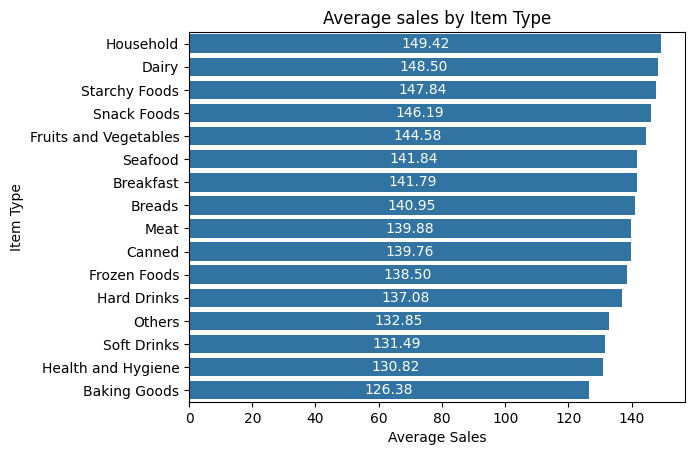

In [ ]:
ax=sns.barplot(x=item_sales.values,y=item_sales.index)
plt.title("Average sales by Item Type")
plt.xlabel("Average Sales")
plt.ylabel("Item Type")
for i, v in enumerate(item_sales.values):
    ax.text(v / 2,
            i,
            f"{v:.2f}",
            color="white",
            va="center",
            ha="center")

plt.show()

From this above chert we can see that Household and Dairy items lead in average sales, showing strong customer dependence on daily-need products. In contrast, Baking Goods and Soft Drinks perform the weakest, suggesting they’re either niche or less frequently purchased categories.

What kind of outlet type change average sales?

In [ ]:
outlet_types = df.groupby("Outlet Type")["Sales"].mean().sort_values(ascending=False)

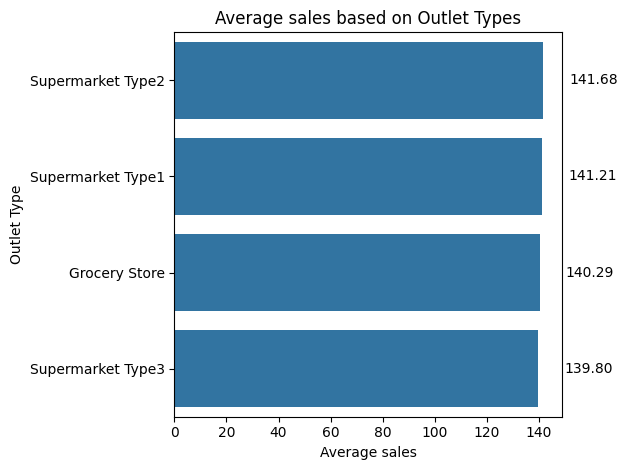

In [ ]:
ax=sns.barplot(x= outlet_types.values, y=outlet_types.index)
plt.title("Average sales based on Outlet Types")
plt.xlabel("Average sales")
plt.ylabel("Outlet Type")
for i, v in enumerate(outlet_types.values):
    ax.text(v + 10,
            i,
            f"{v:.2f}",
            color="black",
            va="center")

plt.tight_layout()
plt.show()

There is no major difference in average sales among outlet types all perform nearly equally. This suggests that factors like location, item type, or visibility may play a more important role in driving sales than outlet type alone.

Which kind of Outlet Size contributes most sales on average?

In [ ]:
outlet_size= df.groupby("Outlet Size")["Sales"].mean().sort_values(ascending=False)

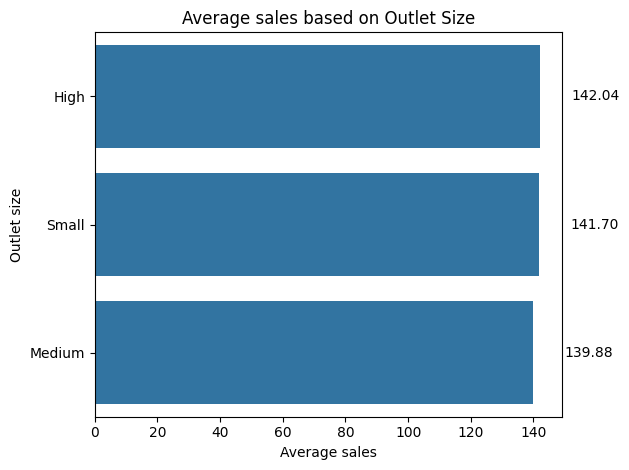

In [ ]:
ax=sns.barplot(x=outlet_size.values,y=outlet_size.index)
plt.title("Average sales based on Outlet Size")
plt.xlabel("Average sales")
plt.ylabel("Outlet size")
for i, v in enumerate(outlet_size.values):
    ax.text(v + 10,
            i,
            f"{v:.2f}",
            color="black",
            va="center")

plt.tight_layout()
plt.show()

The average sales remain consistent across outlet sizes, with only a tiny edge for larger outlets. This indicates that factors like outlet location, product mix, and marketing strategies are likely more influential on sales than physical outlet size.

What is the relation between Sales and Ratings based on Outlet location type?

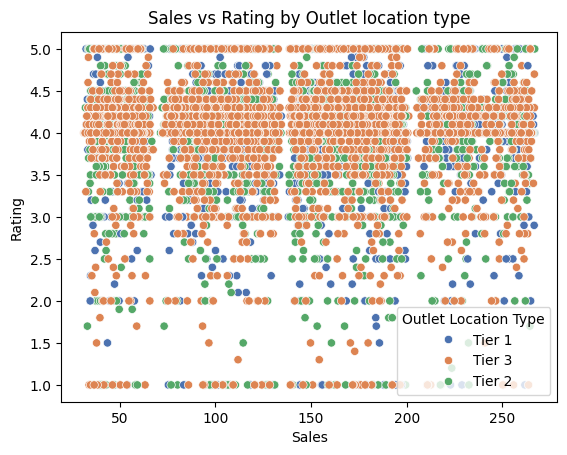

In [ ]:
sns.scatterplot(x="Sales", y="Rating",
hue="Outlet Location Type",data=df,palette="deep")
plt.title("Sales vs Rating by Outlet location type")
plt.xlabel("Sales")
plt.ylabel("Rating")
plt.show()

From this above chert we can understood most outlets are Tier 3, and ratings are generally high (4–5), but there’s no strong correlation between outlet location tier and sales performance.

What is the difference on sale based on Item fat content?

In [ ]:
df['Item Fat Content'] = df['Item Fat Content'].replace({'low fat': 'Low Fat', 'LF': 'Low Fat', 'reg': 'Regular'})
print("Cleaned 'Item Fat Content' values:")
df['Item Fat Content'].value_counts()

Cleaned 'Item Fat Content' values:


,count
Item Fat Content,
Low Fat,5517
Regular,3006


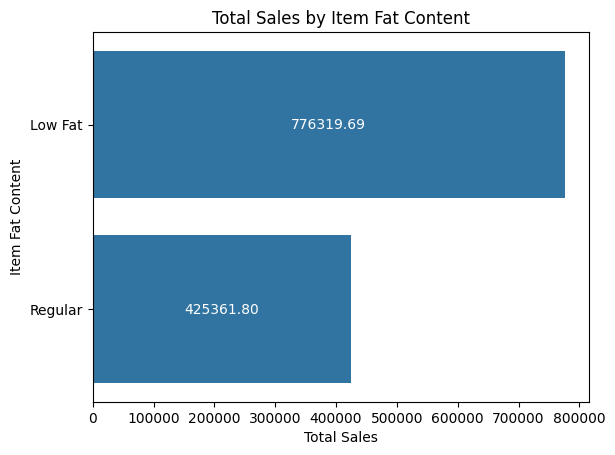

In [ ]:
item_fat_content = df.groupby("Item Fat Content")["Sales"].sum().sort_values(ascending=False)
ax = sns.barplot(x=item_fat_content.values, y=item_fat_content.index)
plt.title("Total Sales by Item Fat Content")
plt.xlabel("Total Sales")
plt.ylabel("Item Fat Content")
for i, v in enumerate(item_fat_content.values):
    ax.text(v / 2,
            i,
            f"{v:.2f}",
            color="white",
            va="center",
            ha="center")

plt.show()

From this above chert we can understood Low fat products are mostly sold.

Which Outlet Establishment Year has most sales on average?

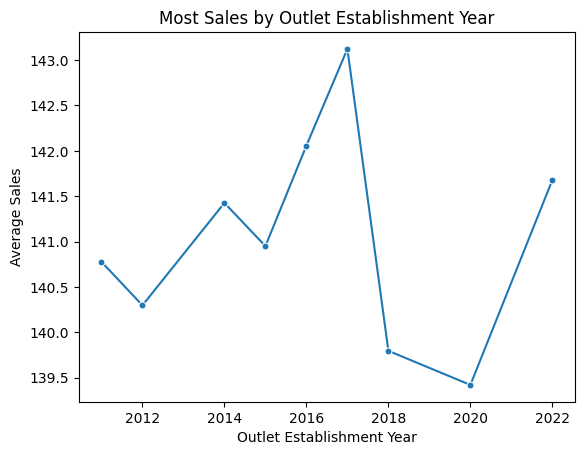

In [ ]:
outlet_establishment_year= df.groupby("Outlet Establishment Year")["Sales"].mean().sort_values(ascending=False)
sns.lineplot(x=outlet_establishment_year.index,y=outlet_establishment_year.values,
             marker = 'o',
             markersize = 5)
plt.title("Most Sales by Outlet Establishment Year")
plt.xlabel("Outlet Establishment Year")
plt.ylabel("Average Sales")
plt.show()

From this above chert we can see outlet performance peaked around 2017, declined sharply in the following years, and began to recover by 2022. This trend suggests cyclical variations in outlet success rather than a consistent pattern tied to establishment year.

Correlation between Item Visibility and Sales

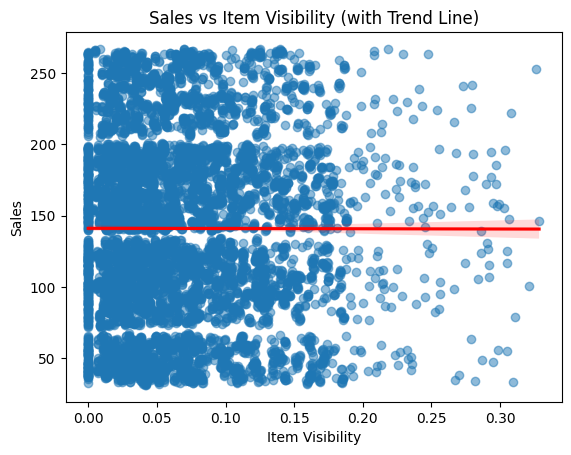

In [ ]:
sns.regplot(x="Item Visibility", y="Sales", data=df, scatter_kws={'alpha':0.5}, line_kws={"color":"red"})

plt.title("Sales vs Item Visibility (with Trend Line)")
plt.xlabel("Item Visibility")
plt.ylabel("Sales")
plt.show()

From this above chert we can see there is no meaningful relationship between an item’s visibility and its sales. This implies that factors other than visibility — such as price, brand, or outlet type likely have a greater influence on sales performance.

Top 5 mostly sold product.

In [ ]:
item_type= df.groupby("Item Type")["Sales"].sum().sort_values(ascending=False).head(5)

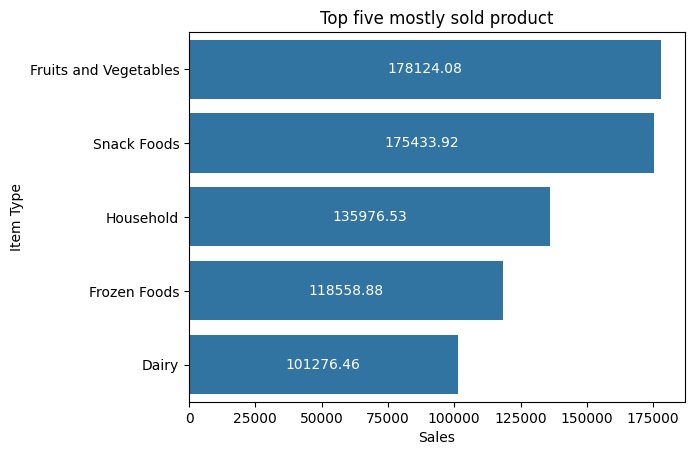

In [ ]:
ax=sns.barplot(x=item_type.values,y=item_type.index)
plt.title("Top five mostly sold product")
plt.xlabel("Sales")
plt.ylabel("Item Type")
for i, v in enumerate(item_type.values):
    ax.text(v / 2,
            i,
            f"{v:.2f}",
            color="white",
            va="center",
            ha="center")

plt.show()

The Fruits & Vegetables and Snack Foods categories dominate total sales, suggesting that daily consumables and ready-to-eat items drive the majority of revenue. In contrast, while Household, Frozen Foods, and Dairy still sell well, they contribute relatively less to total sales volume.

Percentage of Outlet Location Type



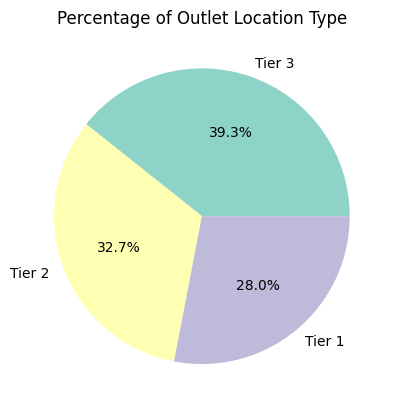

In [ ]:
plt.pie(df['Outlet Location Type'].value_counts(),labels=df['Outlet Location Type'].value_counts().index,autopct='%1.1f%%',
        colors = sns.color_palette('Set3'))
plt.title('Percentage of Outlet Location Type')
plt.show()

The majority of outlets belong to Tier 3 (less urban) regions, followed by Tier 2, while Tier 1 (urban) outlets are the least common. This distribution suggests that the company has a wider rural and semi-urban market presence, possibly targeting broad consumer bases beyond major cities.

Outlet Age

In [ ]:
current_year = 2025
df['Outlet_Age'] = current_year - df['Outlet Establishment Year']

In [ ]:
df['Item_Category'] = df['Item Identifier'].apply(lambda x: x[0:2])
df['Item_Category'] = df['Item_Category'].map({'FD': 'Food', 'NC': 'Non-Consumable', 'DR': 'Drinks'})

In [ ]:
#"Change the values of items whose Visibility is 0"
item_avg_visibility = df.pivot_table(values='Item Visibility', index='Item Identifier', aggfunc='mean')
df.loc[df['Item Visibility'] == 0, 'Item Visibility'] = df.loc[df['Item Visibility'] == 0, 'Item Identifier'].apply(lambda x: item_avg_visibility.loc[x])


In [ ]:
df.head()

,Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type,Item Visibility,Item Weight,Sales,Rating,Outlet_Age,Item_Category
0,Regular,FDX32,Fruits and Vegetables,2012,OUT049,Tier 1,Medium,Supermarket Type1,0.100014,15.10,145.4786,5.0,13,Food
1,Low Fat,NCB42,Health and Hygiene,2022,OUT018,Tier 3,Medium,Supermarket Type2,0.008596,11.80,115.3492,5.0,3,Non-Consumable
2,Regular,FDR28,Frozen Foods,2016,OUT046,Tier 1,Small,Supermarket Type1,0.025896,13.85,165.0210,5.0,9,Food
3,Regular,FDL50,Canned,2014,OUT013,Tier 3,High,Supermarket Type1,0.042278,12.15,126.5046,5.0,11,Food
4,Low Fat,DRI25,Soft Drinks,2015,OUT045,Tier 2,Small,Supermarket Type1,0.033970,19.60,55.1614,5.0,10,Drinks


In [ ]:
encoder = LabelEncoder()

In [ ]:
df['Item Fat Content'] = encoder.fit_transform(df['Item Fat Content'])
df['Item Identifier'] = encoder.fit_transform(df['Item Identifier'])
df['Item Type'] = encoder.fit_transform(df['Item Type'])
df['Outlet Identifier'] = encoder.fit_transform(df['Outlet Identifier'])
df['Outlet Location Type'] = encoder.fit_transform(df['Outlet Location Type'])
df['Outlet Size'] = encoder.fit_transform(df['Outlet Size'])
df['Outlet Type'] = encoder.fit_transform(df['Outlet Type'])
df['Item_Category'] = encoder.fit_transform(df['Item_Category'])

In [ ]:
df.head()

,Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type,Item Visibility,Item Weight,Sales,Rating,Outlet_Age,Item_Category
0,1,1142,6,2012,9,0,1,1,0.100014,15.10,145.4786,5.0,13,1
1,0,1280,8,2022,3,2,1,2,0.008596,11.80,115.3492,5.0,3,2
2,1,843,5,2016,8,0,2,1,0.025896,13.85,165.0210,5.0,9,1
3,1,611,3,2014,1,2,0,1,0.042278,12.15,126.5046,5.0,11,1
4,0,82,14,2015,7,1,2,1,0.033970,19.60,55.1614,5.0,10,0


In [ ]:
#Splitting features and Target
x= df.drop(columns="Sales",axis=1)
y= df["Sales"]

In [ ]:
print(x)

      Item Fat Content  Item Identifier  Item Type  Outlet Establishment Year  \
0                    1             1142          6                       2012   
1                    0             1280          8                       2022   
2                    1              843          5                       2016   
3                    1              611          3                       2014   
4                    0               82         14                       2015   
...                ...              ...        ...                        ...   
8518                 0             1497          8                       2018   
8519                 0              658         13                       2018   
8520                 0               29         14                       2018   
8521                 1              958          4                       2018   
8522                 1              651         13                       2018   

      Outlet Identifier  Ou

In [ ]:
print(y)

0       145.4786
1       115.3492
2       165.0210
3       126.5046
4        55.1614
          ...   
8518    164.5526
8519    241.6828
8520     86.6198
8521     97.8752
8522    112.2544
Name: Sales, Length: 8523, dtype: float64


In [ ]:
#Splitting the data into Training data and Testing data
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=2)

In [ ]:
print(x.shape,x_train.shape,x_test.shape)

(8523, 13) (6818, 13) (1705, 13)


In [ ]:
regressor = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    max_depth=None
)


In [ ]:
regressor.fit(x_train,y_train)

RandomForestRegressor(n_estimators=300, random_state=42)

**Evaluation**

In [ ]:
#Prediction on traning data
traning_data_prediction=regressor.predict(x_train)

In [ ]:
#R square value
r2_train=metrics.r2_score(y_train,traning_data_prediction)

In [ ]:
print("R square value:",r2_train)

R square value: 0.9658554347882395


In [ ]:
#Prediction on testing data
test_data_prediction=regressor.predict(x_test)

In [ ]:
#R square value
r2_test=metrics.r2_score(y_test,test_data_prediction)

In [ ]:
print("R square value:",r2_test)

R square value: 0.733091225575332


In [ ]:
mae = metrics.mean_absolute_error(y_test,test_data_prediction )
mse = metrics.mean_squared_error(y_test, test_data_prediction)
rmse = np.sqrt(mse)

In [ ]:
print(" Model Performance Summary:")
print(f"R² Score (Training): {r2_train:.3f}")
print(f"R² Score (Testing):  {r2_test:.3f}")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}\n")

 Model Performance Summary:
R² Score (Training): 0.966
R² Score (Testing):  0.733
MAE: 22.44
RMSE: 32.50



In [ ]:
print(" Displaying prediction chart...")

y_pred_sample = test_data_prediction[:50]
y_actual_sample = y_test.iloc[:50]

 Displaying prediction chart...


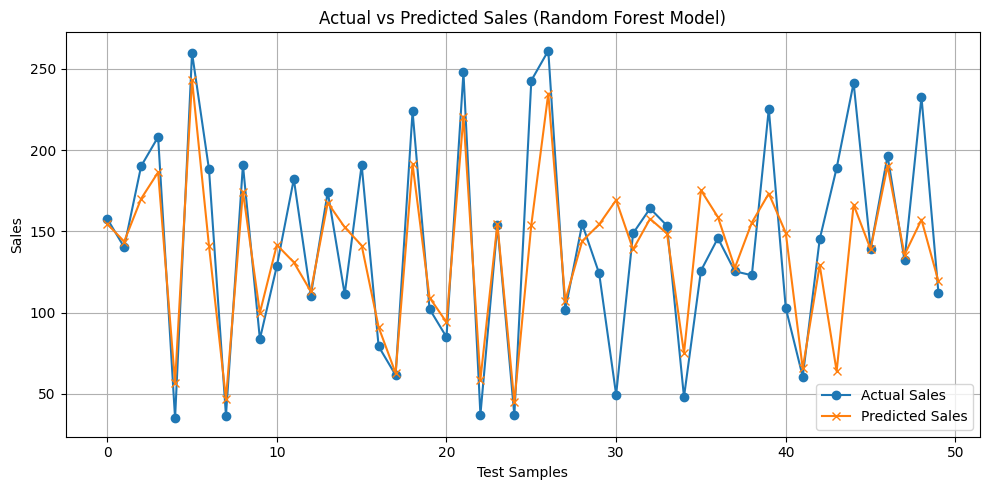

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(range(50), y_actual_sample, label="Actual Sales", marker='o')
plt.plot(range(50), y_pred_sample, label="Predicted Sales", marker='x')
plt.title("Actual vs Predicted Sales (Random Forest Model)")
plt.xlabel("Test Samples")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Summary: Actual vs Predicted Sales (Random Forest Model)

From the graph, we can observe the following:

The actual and predicted values are closely aligned, which means the Random Forest model has captured the underlying pattern fairly well.

At some points — especially where the actual values are extremely high or low —
the predictions deviate slightly, which is normal for Random Forest when the data contains high variability or outliers.

Overall, the ups and downs of both curves follow a similar trend, indicating that the model performs consistently.

The prediction errors are not very large, meaning
the model provides reasonably accurate results.

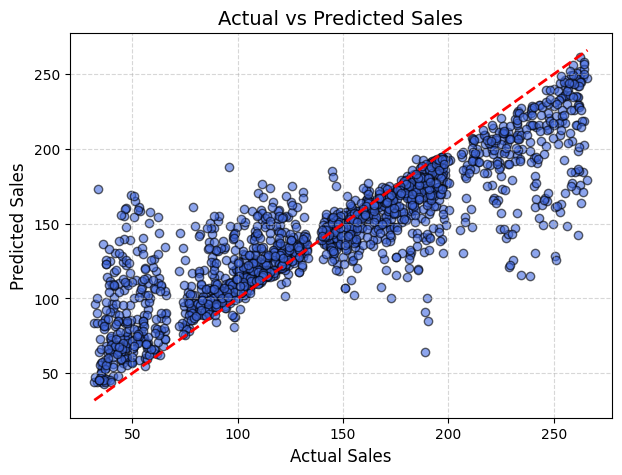

In [ ]:
y_test = np.array(y_test)
y_pred = np.array(test_data_prediction)

plt.figure(figsize=(7,5))
plt.scatter(y_test, y_pred, color='royalblue', alpha=0.6, edgecolor='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2, linestyle='--')

plt.title("Actual vs Predicted Sales", fontsize=14)
plt.xlabel("Actual Sales", fontsize=12)
plt.ylabel("Predicted Sales", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Summary: Actual vs Predicted Sales (Scatter Plot)

Strong Positive Relationship
The points follow an upward pattern — as actual sales increase, predicted sales also increase. This shows the model has learned the overall trend well.

Close to Perfect Line
Many points lie close to the red dashed line (the perfect prediction line), meaning the model is making accurate predictions for a large portion of the data.

Some Spread / Variance
There is moderate scatter around the line, especially:

In lower sales (40–100 range)

In mid-range sales (120–180)

Slight spread in high sales (220+)

This indicates some prediction error, but not extremely high.

Model Performance Looks Good
Since most points cluster around the ideal line, the Random Forest model performs reliably and captures patterns effectively.

No major outliers
There are no extreme points far away from the line, which is a good sign for model stability.

In [ ]:
'''print("\n Project completed successfully! ")
input("\nPress Enter to exit...")'''


 Project completed successfully! 

Press Enter to exit...


''